In [12]:
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import seaborn as sns
import numpy as np


In [13]:
df = pd.read_csv("../Data/horror_movies.csv")

df.drop(['adult', 'collection', 'poster_path','backdrop_path'], axis=1, inplace=True)
df.dropna(subset=['overview'], inplace=True)
df['release_date'] = pd.to_datetime(df['release_date'])
df_released = df.drop(df[df['status'] != 'Released'].index).reset_index(drop=True)
movie_df = df_released



# movie_df.info()

#### What makes a Horror Movie Profitable?
#### What makes a Horror Movie Popular? 
#### Is it smarter to make a low budget horror movie in hopes that resonates enough with audiences to become a classic? 
### What is the **IT** factor that can leads to a horror movie making a high revenue and gaining high popularity? 

#### Overall Color Scheme Choice:
I am currently doing alot of comparisons of budgets and revenues, so I felt like green was a good color choice to represent money. I considered darker colors(reds, blacks, etc) that matched the horror aesthetic but found those colors to be jarring and conveying an intensity that I don't necessarily want to be the focus of my analysis. I used a peach tone to compliment the bluer tone of the green I choose for acessibility and for a calmer aesthetic than the stereotypical horror color schemes. As I continue this project, my color scheme might shift and these early visualizations in green might even eventually convey a newness(the beginning) of the project.  
    
I do like how the red and black look for the horror movie release date frequency histogram (firstlook_visuals/horror_movie_release_freq.png) and might use this color scheme for visuals that make a specific point but don't need further visuals to support that insight.

##### Plot Choices Disclaimer:
I did want to experiment with different types of charts for practice; this guided some of my process.

C:\Users\jessi\AppData\Local\Temp\ipykernel_18204\3724541056.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(custom_labels, color = "#327506", fontsize=10, fontweight="bold", rotation=30, ha="right")


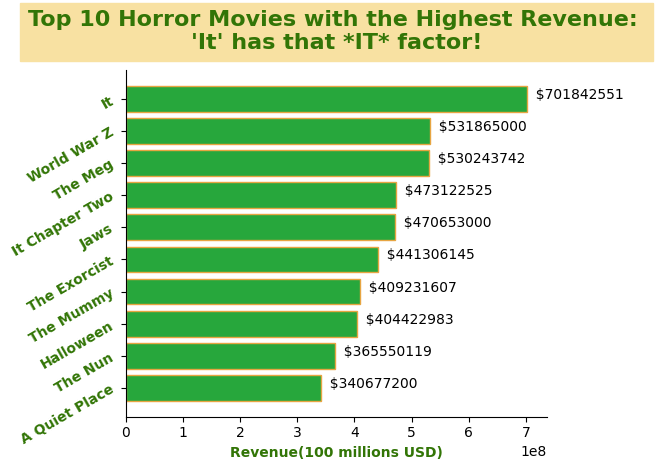

In [14]:
category = "title"
values = "revenue"
movie_rev = movie_df.groupby(category)[values].sum().sort_values(ascending=False)
movie_rev_10 = movie_rev.head(10)



fig, ax = plt.subplots()


ax.barh(movie_rev_10.index, movie_rev_10.values, align='center', edgecolor= "#E7A542", color="#27A73C")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()  
ax.set_xlabel('Revenue(100 millions USD)', color= "#327506", fontweight= 'bold')
ax.set_title("Top 10 Horror Movies with the Highest Revenue: \n'It' has that *IT* factor!", color= "#327506", backgroundcolor= "#f8e1a2",fontsize=16, fontweight='bold', pad= 15)

custom_labels = movie_rev_10.index
ax.set_yticklabels(custom_labels, color = "#327506", fontsize=10, fontweight="bold", rotation=30, ha="right")


for index, value in enumerate(movie_rev_10.values):
    plt.text(value + 50, index, str(f"  ${movie_rev_10.values[index]}"))

plt.tight_layout()
plt.savefig('../exploratory_visuals/top_movie_rev.png')
plt.show()

#### for the above chart:
I used a bar plot to show a compraison of the top ten horror movies with the highest revenues. I thought a horizontal bar plot looked better for this comparison than vertical; the titles are more pronounced and easier to read. 


C:\Users\jessi\AppData\Local\Temp\ipykernel_18204\3290681985.py:35: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend = ax.legend(


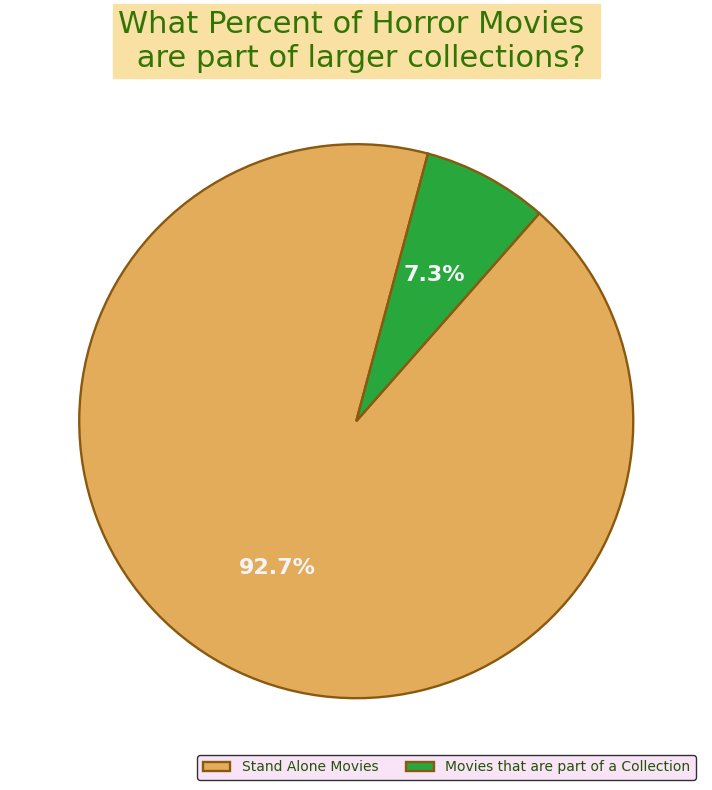

In [15]:
standalone = movie_df['collection_name'].isna().sum()
incollection = movie_df['collection_name'].count()
pie_data = [standalone, incollection]
pie_series = pd.Series(pie_data)


fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotext = ax.pie(
    pie_series,
    labels=None,
    startangle= 75,
    colors=["#E2AC5B", "#27A73C"],
    autopct= "%1.1f%%",
    wedgeprops={
        'edgecolor': "#8A5910", 
        'linewidth': 1.7,     
        'antialiased': True}
    )

ax.set_title(
    "What Percent of Horror Movies \n are part of larger collections?",
    fontsize= 22,
    color= "#327506",
    backgroundcolor= "#f8e1a2",
    loc="center"
    )

for autotext in autotext:
    autotext.set_fontsize(16)
    autotext.set_color("#f4f4f8")
    autotext.set_weight("bold")


legend = ax.legend(
    wedges,
    pie_series.index,
    labels= ["Stand Alone Movies","Movies that are part of a Collection"],
    loc="center right",
    bbox_to_anchor = (1, 0),
    ncol= 2,
    frameon=True,                     
    facecolor="#F8DEF5",           
    edgecolor='black'   
)
for text in legend.get_texts():
    text.set_color("#235205")



plt.tight_layout()

plt.savefig('../exploratory_visuals/collectionvsstanalone.png')
plt.show()





#### for the above chart:  
I used a pie chart to show portions (either movies that are part of a collection, or movies that are not) of a whole(all horror movies).  
  
Not every movie(or specifically the creators of the movie) hope to become part of a larger collection, but many would probably like to(more movies = more revenue). I thought it would be interesting to see the percantage of movies that are part of a collection compared to those that aren't.    
  
Is becoming a collection driven by the initial movies revenue, popularity, etc? What drives those factors?  
  
This chart is not about money so I used the peach color for the larger slice of the pie to guide away from that line of thinking. But I feel like it connects to the "part of a collection" section in the sense that a collection will logically make more money overall than a standalone move.


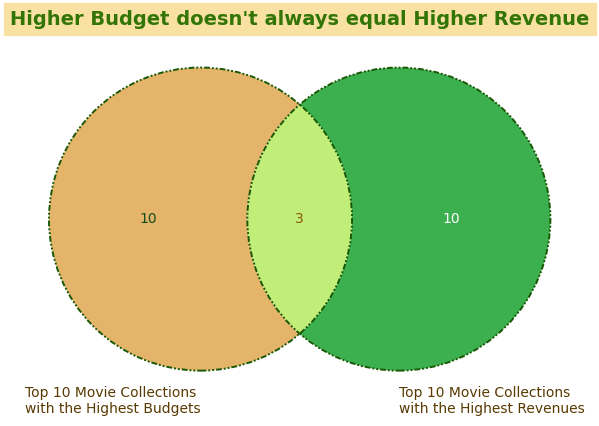

In [16]:

movie_collection_revenue = movie_df.groupby('collection_name')['revenue'].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False).head(10)
movie_coll_rev = pd.Series(movie_coll_rev) 
movie_coll_rev

movie_collection_budget = movie_df.groupby('collection_name')['budget'].sum()
movie_coll_budget = movie_collection_budget.sort_values(ascending=False).head(10)
movie_coll_budget = pd.Series(movie_coll_budget) 
movie_coll_budget

lside = movie_coll_budget.index
rside = movie_coll_rev.index
middle = set(lside).intersection(set(rside))


# print("left:\n")
# print(lside)

# print("right:\n")
# print(rside)

# print("intersection: \n")
# print(middle)

venn = venn2(subsets = (10, 10, 3),
    set_labels = ('Top 10 Movie Collections \nwith the Highest Budgets', 'Top 10 Movie Collections \nwith the Highest Revenues'), 
    set_colors=("#E2AC5B", "#27A73C"),
    alpha= 0.9)

venn2_circles(subsets=(10,10,3),
            color= "#195805",
            linestyle= (0, (3, 1, 1, 1, 1, 1)),
            linewidth= 1.4) 

venn.set_labels[0].set_fontsize(10)
venn.set_labels[1].set_fontsize(10)
venn.set_labels[0].set_color("#583a01")
venn.set_labels[1].set_color("#583a01")

if venn.get_label_by_id('10'):  # leftside
    venn.get_label_by_id('10').set_color( "#114D1B")

if venn.get_label_by_id('01'):  # rigthside
    venn.get_label_by_id('01').set_color('white')

if venn.get_label_by_id('11'):  # intersection
    venn.get_label_by_id('11').set_color("#8B5605")


plt.title("Higher Budget doesn't always equal Higher Revenue",
        color= "#327506",
        backgroundcolor= "#f8e1a2",
        fontsize=14,
        fontweight="bold",
        pad= 5)

plt.tight_layout()
plt.savefig('../exploratory_visuals/collrev_bud_Venn.png')
plt.show()

#### for the above chart:  

I used a Venn diagram to compare similarities (movie collections with the highest revenues **and** the highest budgets).    
In theory, using logic these two circles should be very similar (eclipse one another). But of 17 movie collections only 3 fall into both categories.  
  
I used the top 10 movie collections(in both catgories) instead of the top ten movies because these movies had the longevity to become collections (although I might later make a comparison of the top 10 movies in both categories).  
  
In this chart I used the green on the revenue side to represent money coming in, and I feel like the peach color keeps a calm tone about the money being spent (where as a red would be too intense and imply money loss, and would also come with accessibility issues- color blindness). A budget is needed (even a small one) and I don't want it to be see as a jarring expenditure. 


### Below is a list of the movies in each category from the Venn Diagram as well as Bar Charts with the values for each Movie in these categories. 


### Top Ten Collections with Highest Budgets:  
Resident Evil Collection  
Blade Collection  
Final Destination Collection  
Van Helsing Collection  
The Meg Collection  
The Exorcist Collection  
Scream Collection  
Alien Collection  
The Hannibal Lecter Collection  
The Ring Collection  
  

### Top Ten Collections with Highest Revenue:  
Resident Evil Collection  
It Collection  
Saw Collection  
Paranormal Activity Collection  
The Conjuring Collection  
Jaws Collection  
Annabelle Collection  
Scream Collection  
Final Destination Collection  
Halloween Collection  
  

### Collections withinTop Ten Highest Budgets __and__ Top Ten Highest Revenue  
Final Destination Collection  
Scream Collection  
Resident Evil Collection

C:\Users\jessi\AppData\Local\Temp\ipykernel_18204\2064925733.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, color = "#234603", backgroundcolor= "#f7dbb7", fontsize=10, fontweight="bold", rotation=30, ha="right")


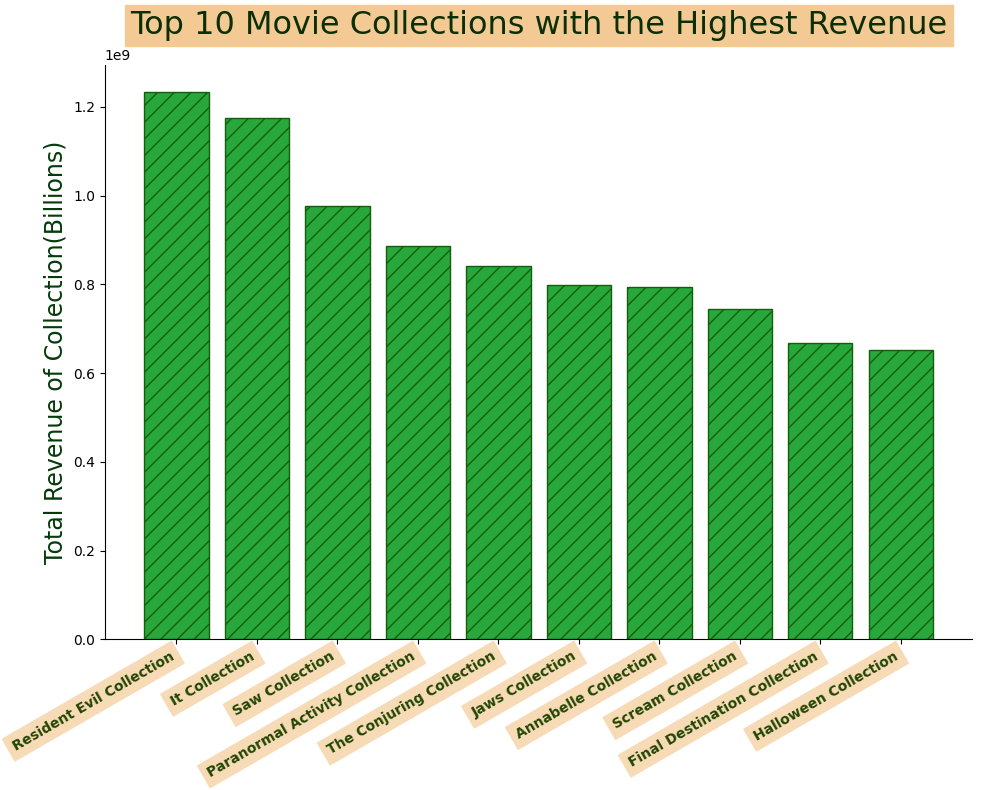

In [17]:
category = "collection_name"
values = "revenue"
movie_collection_revenue = movie_df.groupby(category)[values].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False) 

collection_rev_10 = movie_coll_rev.head(10)

plt.figure(figsize=(10,8))
plt.bar(collection_rev_10.index, collection_rev_10.values, color= "#27A73C", edgecolor= "#145f0a", hatch= "//")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Top 10 Movie Collections with the Highest Revenue",
          fontsize= 23,
          color= "#0B2E02",
          backgroundcolor= "#f3ca94",
          pad= 22,
          loc="center")

plt.ylabel("Total Revenue of Collection(Billions)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

custom_labels = collection_rev_10.index
ax.set_xticklabels(custom_labels, color = "#234603", backgroundcolor= "#f7dbb7", fontsize=10, fontweight="bold", rotation=30, ha="right")

plt.tight_layout()
plt.savefig('../exploratory_visuals/top_movie_collection_rev.png')
plt.show()

C:\Users\jessi\AppData\Local\Temp\ipykernel_18204\4053873450.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, color = "#234603", backgroundcolor= "#ebc491", fontsize=10, fontweight="bold", rotation=30, ha="right")


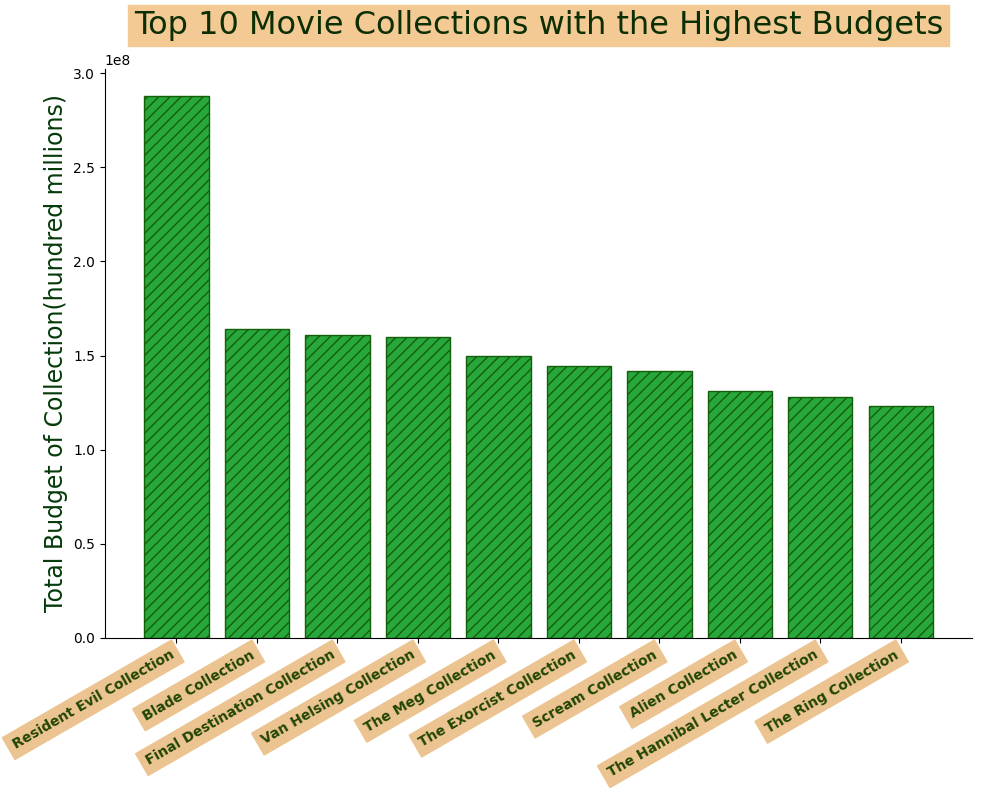

In [18]:
category = "collection_name"
values = "budget"
movie_collection_budget = movie_df.groupby(category)[values].sum()
movie_coll_budget = movie_collection_budget.sort_values(ascending=False) 

collection_budget_10 = movie_coll_budget.head(10)
# print(collection_budget_10)


plt.figure(figsize=(10,8))
plt.bar(collection_budget_10.index, collection_budget_10.values, color= "#27A73C", edgecolor= "#145f0a", hatch= "///")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Top 10 Movie Collections with the Highest Budgets",
          fontsize= 23,
          color= "#0B2E02",
          backgroundcolor= "#f3ca94",
          pad= 25,
          loc="center")

plt.ylabel("Total Budget of Collection(hundred millions)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

custom_labels = collection_budget_10.index
ax.set_xticklabels(custom_labels, color = "#234603", backgroundcolor= "#ebc491", fontsize=10, fontweight="bold", rotation=30, ha="right")

plt.tight_layout()
plt.savefig('../exploratory_visuals/top_movie_collection_budget.png')
plt.show()
